# Load Data

In [1]:
import pandas as pd
import os

# Define file paths for the datasets
train_path = "datasets/banking77_train.csv"
test_path = "datasets/banking77_test.csv"

# Check if the dataset files exist before loading
if os.path.exists(train_path) and os.path.exists(test_path):
    print("✅ Datasets found successfully!")
    
    # Load training and testing data
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    
    # Display the number of samples in each set
    print(f"Training set: {df_train.shape[0]} samples")
    print(f"Testing set: {df_test.shape[0]} samples")
else:
    print("❌ Error: Dataset files not found in 'datasets/'. Please check the directory.")

# Display the first few rows of the training data
df_train.head()

✅ Datasets found successfully!
Training set: 10003 samples
Testing set: 3080 samples


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


# Check Data

In [2]:
def check_data_quality(df, name):
    """
    Perform a basic data quality audit on a given DataFrame.
    Checks for missing values, empty strings, and unique class counts.
    """
    print(f"\n--- Data Quality Audit: {name} ---")
    
    # Check for null/NaN values across all columns
    null_counts = df.isnull().sum()
    print(f"Missing Values:\n{null_counts}")
    
    # Identify empty queries (strings containing only whitespace)
    empty_queries = (df['text'].str.strip() == "").sum()
    print(f"Empty text queries (whitespace only): {empty_queries}")
    
    # Verify the number of unique intent categories (Expected: 77)
    unique_intents = df['category'].nunique()
    print(f"Unique Intent Categories: {unique_intents}")

# Execute audit for both sets
check_data_quality(df_train, "Training Dataset")
check_data_quality(df_test, "Testing Dataset")


--- Data Quality Audit: Training Dataset ---
Missing Values:
text        0
category    0
dtype: int64
Empty text queries (whitespace only): 0
Unique Intent Categories: 77

--- Data Quality Audit: Testing Dataset ---
Missing Values:
text        0
category    0
dtype: int64
Empty text queries (whitespace only): 0
Unique Intent Categories: 77


# Visualize and Explore Data

## Train dataset visualization

C:\Users\bmonteir\AppData\Local\Temp\ipykernel_17032\777869413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


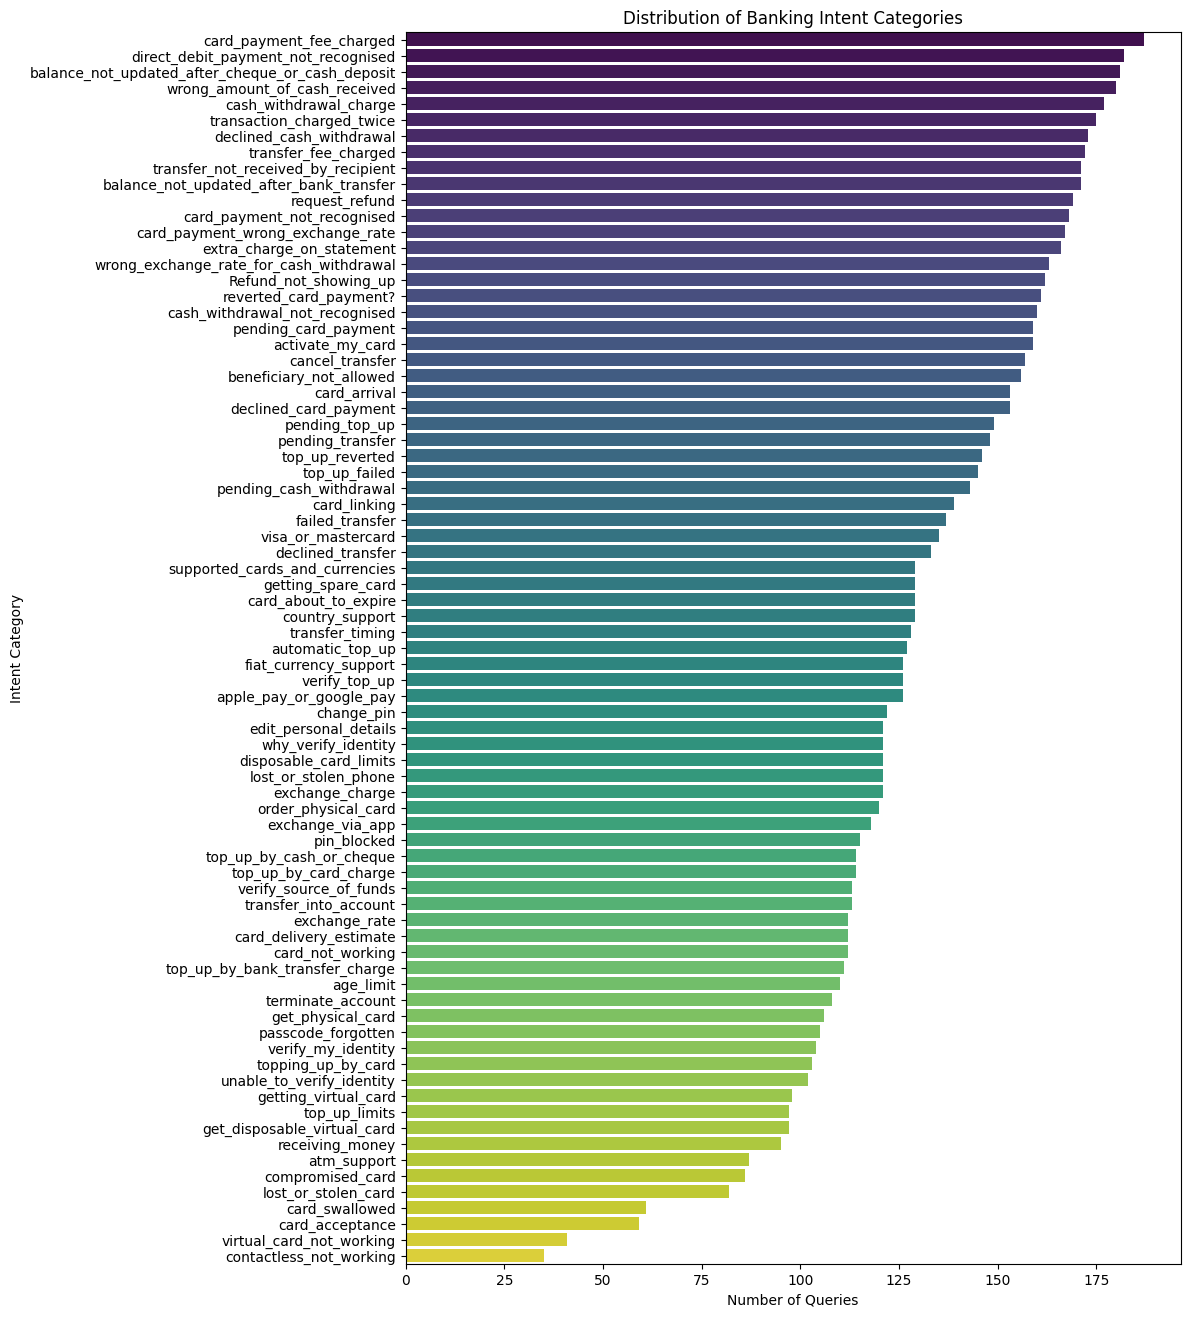

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 16))

# Plot a horizontal countplot ordered by frequency
sns.countplot(
    data=df_train, 
    y='category', 
    order=df_train['category'].value_counts().index,
    palette='viridis'
)

# Add informative title and labels in English
plt.title('Distribution of Banking Intent Categories')
plt.xlabel('Number of Queries')
plt.ylabel('Intent Category')
plt.show()

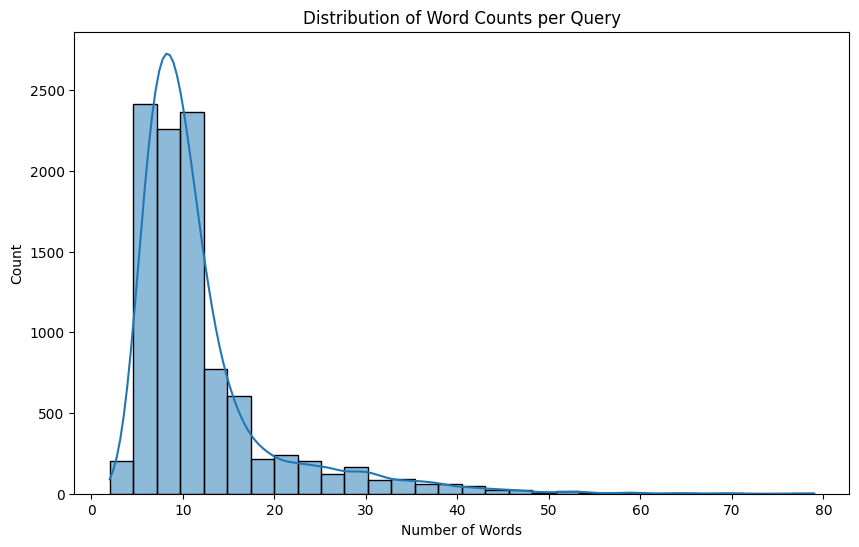

        char_length    word_count
count  10003.000000  10003.000000
mean      59.475057     11.949415
std       40.867716      7.891577
min       13.000000      2.000000
25%       36.000000      7.000000
50%       47.000000     10.000000
75%       64.000000     13.000000
max      433.000000     79.000000


In [4]:
# Calculate character length and word count for each query
df_train['char_length'] = df_train['text'].apply(len)
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))

# Visualize the distribution of word counts
plt.figure(figsize=(10, 6))
sns.histplot(df_train['word_count'], bins=30, kde=True)
plt.title('Distribution of Word Counts per Query')
plt.xlabel('Number of Words')
plt.show()

# Get descriptive statistics for these new columns
print(df_train[['char_length', 'word_count']].describe())

In [5]:
# Check for duplicate queries in the training set
duplicates = df_train.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If you want to see which ones are duplicated:
# df_train[df_train.duplicated(keep=False)].sort_values(by='text').head()

Number of duplicate rows: 0


## Test dataset visualization

C:\Users\bmonteir\AppData\Local\Temp\ipykernel_17032\3964874627.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


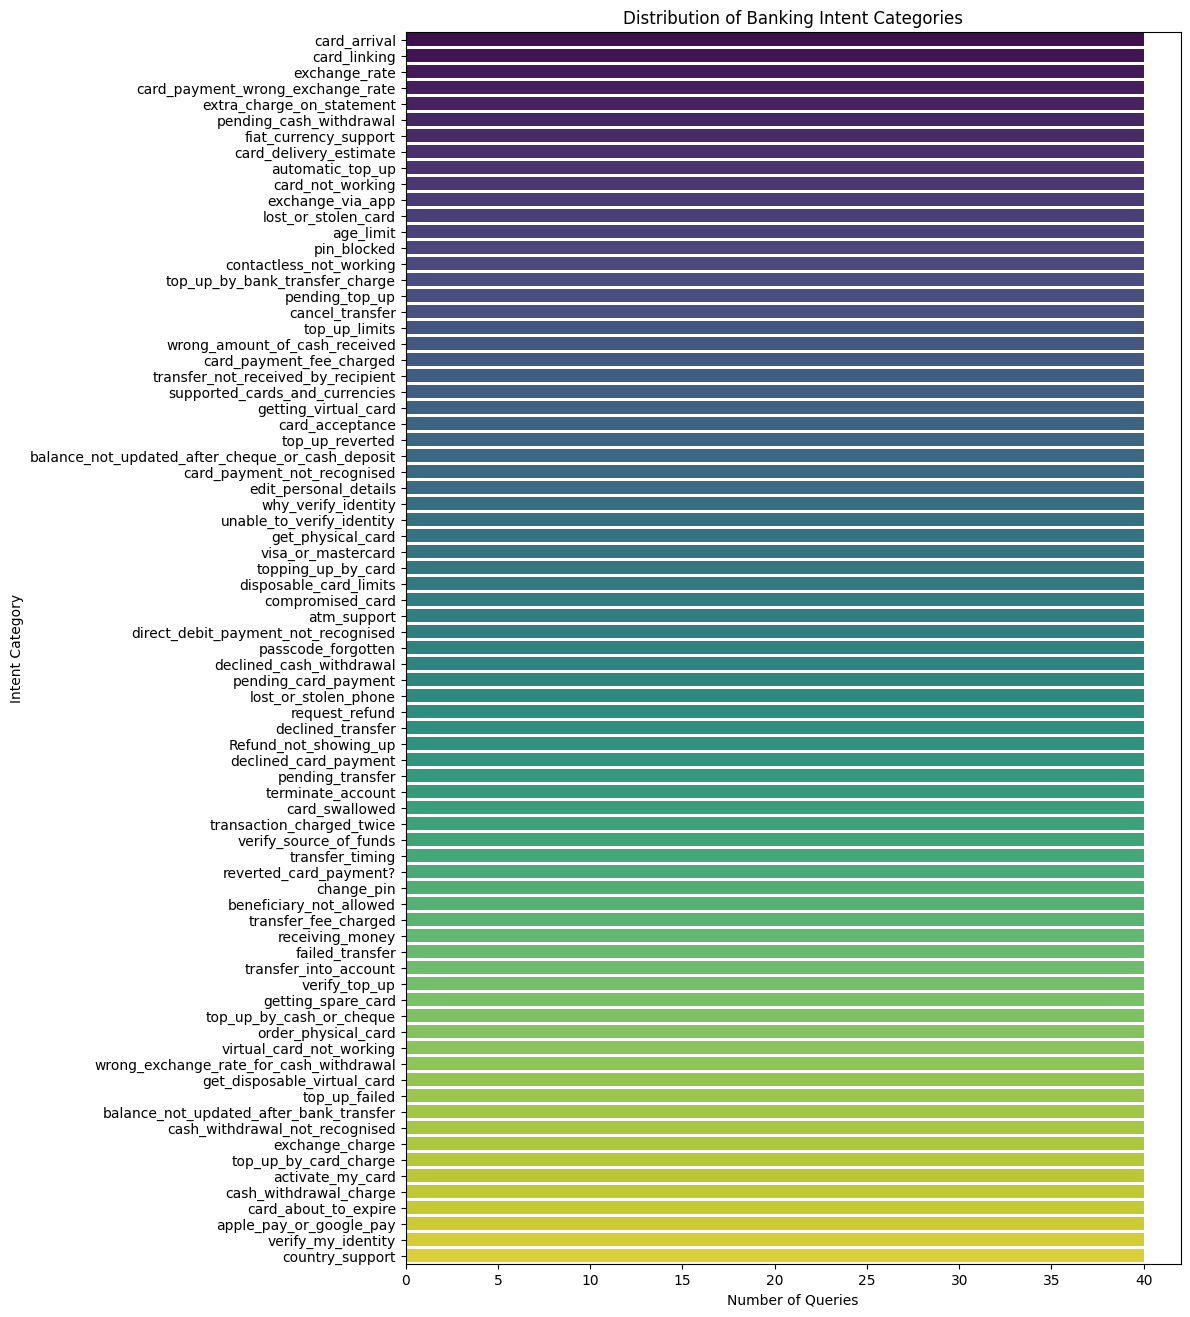

In [6]:
plt.figure(figsize=(10, 16))

# Plot a horizontal countplot ordered by frequency
sns.countplot(
    data=df_test, 
    y='category', 
    order=df_test['category'].value_counts().index,
    palette='viridis'
)

# Add informative title and labels in English
plt.title('Distribution of Banking Intent Categories')
plt.xlabel('Number of Queries')
plt.ylabel('Intent Category')
plt.show()


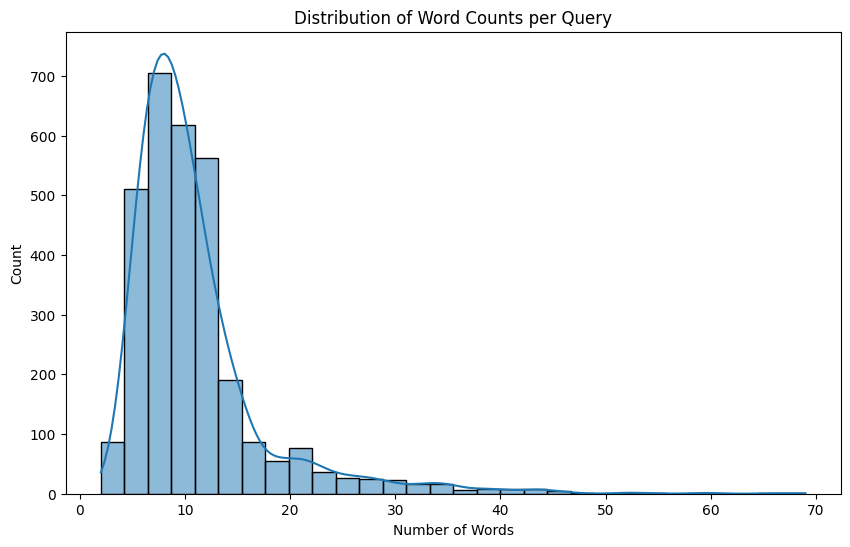

       char_length   word_count
count  3080.000000  3080.000000
mean     54.233766    10.952597
std      34.657249     6.688180
min      13.000000     2.000000
25%      35.000000     7.000000
50%      45.000000     9.000000
75%      60.000000    12.000000
max     368.000000    69.000000


In [7]:
# Calculate character length and word count for each query
df_test['char_length'] = df_test['text'].apply(len)
df_test['word_count'] = df_test['text'].apply(lambda x: len(x.split()))

# Visualize the distribution of word counts
plt.figure(figsize=(10, 6))
sns.histplot(df_test['word_count'], bins=30, kde=True)
plt.title('Distribution of Word Counts per Query')
plt.xlabel('Number of Words')
plt.show()

# Get descriptive statistics for these new columns
print(df_test[['char_length', 'word_count']].describe())

In [8]:
# Check for duplicate queries in the training set
duplicates = df_test.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If you want to see which ones are duplicated:
# df_test[df_test.duplicated(keep=False)].sort_values(by='text').head()

Number of duplicate rows: 0


# Multi-Layer Perceptron: Preprocessing

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the TF-IDF Vectorizer to convert text into numerical features
# We limit to 5000 features to keep the baseline model efficient
vectorizer = TfidfVectorizer(max_features=5000)

# 2. Initialize the Label Encoder to convert category names into integers (0-76)
le = LabelEncoder()


# 3. Fit the vectorizer on training text and transform both train and test sets
# 'fit_transform' learns the vocabulary; 'transform' only applies it to new data
X_train = vectorizer.fit_transform(df_train['text'])
X_test = vectorizer.transform(df_test['text'])

# 4. Convert text labels into numerical IDs for the model to process
# Each banking intent (e.g., 'card_arrival') becomes a unique number
y_train = le.fit_transform(df_train['category'])
y_test = le.transform(df_test['category'])

print(f"Total number of unique banking intents: {len(le.classes_)}")
print(f"X_train shape: {X_train.shape}") # Expected: (num_samples, 5000)
print(f"y_train shape: {y_train.shape}") # Expected: (num_samples,)
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Total number of unique banking intents: 77
X_train shape: (10003, 2320)
y_train shape: (10003,)
X_test shape: (3080, 2320)
y_test shape: (3080,)


# Multi-Layer Perceptron: Training and Evaluation


In [10]:
import torch.nn as nn

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLPClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out
    

# Define dimensions based on our data
input_dim = X_train.shape[1]  # Number of features from TF-IDF
hidden_dim = 128  # Size of the hidden layer (can be tuned)
output_dim = len(le.classes_)  # Number of unique intent categories (77)

# Initialize the model
model = MLPClassifier(input_dim, hidden_dim, output_dim)
print(model)

MLPClassifier(
  (fc1): Linear(in_features=2320, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=77, bias=True)
)


### Creating criterion and optimizer

In [11]:
import torch.optim as optim

# 1. Cross-Entropy Loss: The standard for multi-class classification (77 intents)
# It measures the distance between the predicted probability and the true label
criterion = nn.CrossEntropyLoss()

# 2. AdamW Optimizer: A robust version of Adam that handles 'Weight Decay' better
# Weight decay helps prevent overfitting by keeping weights small
# lr=0.001 is a common starting point for learning rate
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

### Turning train and test matrix into tensors

In [12]:
import torch

# Convert Scikit-learn Sparse Matrix to PyTorch Dense Tensors
# 1. X_train needs to be a Float tensor
X_train_t = torch.tensor(X_train.toarray()).float()
X_test_t = torch.tensor(X_test.toarray()).float()

# 2. y_train needs to be a Long tensor (integers) for CrossEntropyLoss
y_train_t = torch.tensor(y_train).long()
y_test_t = torch.tensor(y_test).long()

print(f"Data successfully converted to PyTorch Tensors.")

Data successfully converted to PyTorch Tensors.


### Training the model

In [13]:
epochs = 100
train_losses = []
train_accuracies = []

print("Starting training loop...")

for epoch in range(epochs):
    model.train() # Set model to training mode
    
    # 1. Forward Pass: Get predictions
    outputs = model(X_train_t)
    
    # 2. Calculate Loss
    loss = criterion(outputs, y_train_t)
    
    # 3. Backward Pass: Compute gradients
    optimizer.zero_grad() # Clear old gradients
    loss.backward()       # Backpropagation
    
    # 4. Update Parameters
    optimizer.step()      # Update weights and biases
    
    # --- Calculate Metrics for the Epoch ---
    # Convert outputs to predicted classes (the index with the highest value)
    _, predicted = torch.max(outputs, 1)
    
    # Accuracy calculation
    correct = (predicted == y_train_t).sum().item()
    accuracy = correct / y_train_t.size(0)
    
    # Save metrics for plotting later
    train_losses.append(loss.item())
    train_accuracies.append(accuracy)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f} - Accuracy: {accuracy:.4f}")

print("Training Complete!")

Starting training loop...
Epoch [5/100] - Loss: 4.3292 - Accuracy: 0.0398
Epoch [10/100] - Loss: 4.3044 - Accuracy: 0.0630
Epoch [15/100] - Loss: 4.2710 - Accuracy: 0.1286
Epoch [20/100] - Loss: 4.2297 - Accuracy: 0.2344
Epoch [25/100] - Loss: 4.1802 - Accuracy: 0.3429
Epoch [30/100] - Loss: 4.1223 - Accuracy: 0.4162
Epoch [35/100] - Loss: 4.0558 - Accuracy: 0.4657
Epoch [40/100] - Loss: 3.9807 - Accuracy: 0.4962
Epoch [45/100] - Loss: 3.8970 - Accuracy: 0.5240
Epoch [50/100] - Loss: 3.8047 - Accuracy: 0.5556
Epoch [55/100] - Loss: 3.7039 - Accuracy: 0.5906
Epoch [60/100] - Loss: 3.5947 - Accuracy: 0.6239
Epoch [65/100] - Loss: 3.4770 - Accuracy: 0.6554
Epoch [70/100] - Loss: 3.3510 - Accuracy: 0.6878
Epoch [75/100] - Loss: 3.2170 - Accuracy: 0.7078
Epoch [80/100] - Loss: 3.0757 - Accuracy: 0.7292
Epoch [85/100] - Loss: 2.9279 - Accuracy: 0.7493
Epoch [90/100] - Loss: 2.7746 - Accuracy: 0.7644
Epoch [95/100] - Loss: 2.6174 - Accuracy: 0.7773
Epoch [100/100] - Loss: 2.4581 - Accuracy: 0

### Evaluating the trained model on the test dataset

In [16]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Ensure the model is in evaluation mode
model.eval()

# 2. Get predictions for both sets to compare
with torch.no_grad():
    # Training predictions
    train_outputs = model(X_train_t)
    _, train_preds = torch.max(train_outputs, 1)
    
    # Testing predictions
    test_outputs = model(X_test_t)
    _, test_preds = torch.max(test_outputs, 1)

# 3. Calculate Metrics
train_acc = accuracy_score(y_train_t.numpy(), train_preds.numpy())
test_acc = accuracy_score(y_test_t.numpy(), test_preds.numpy())

# Aggregated Statistics (Testing Set)
macro_f1 = f1_score(y_test_t.numpy(), test_preds.numpy(), average='macro')
weighted_f1 = f1_score(y_test_t.numpy(), test_preds.numpy(), average='weighted')

# 4. Final Comparison Output
print("======= MLP BASELINE FINAL EVALUATION =======")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Generalization Gap: {(train_acc - test_acc):.4f}")
print("---------------------------------------------")
print(f"Macro F1 Score (Test):    {macro_f1:.4f}")
print(f"Weighted F1 Score (Test): {weighted_f1:.4f}")
print("=============================================\n")

# 5. Full Classification Report for the Test Set
print("Detailed Test Classification Report:")
print(classification_report(y_test_t.numpy(), test_preds.numpy(), target_names=le.classes_))

======= MLP BASELINE FINAL EVALUATION =======
Training Accuracy: 0.7929
Testing Accuracy:  0.6724
Generalization Gap: 0.1205
---------------------------------------------
Macro F1 Score (Test):    0.6524
Weighted F1 Score (Test): 0.6524

Detailed Test Classification Report:
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.72      0.78      0.75        40
                                activate_my_card       0.51      0.90      0.65        40
                                       age_limit       0.97      0.95      0.96        40
                         apple_pay_or_google_pay       0.89      1.00      0.94        40
                                     atm_support       0.75      0.23      0.35        40
                                automatic_top_up       0.69      0.88      0.77        40
         balance_not_updated_after_bank_transfer       0.53      0.62      0.57        40
bala

c:\Users\bmonteir\Documents\ai_engineer_journey\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bmonteir\Documents\ai_engineer_journey\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bmonteir\Documents\ai_engineer_journey\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

# RoBERTa Transformer: Preprocessing

In [1]:
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Carregamento
df_train = pd.read_csv('datasets/banking77_train.csv')
df_test = pd.read_csv('datasets/banking77_test.csv')

model_checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
target_col = 'category' 

# 1. Encoding dos Labels
le = LabelEncoder()
df_train['labels'] = le.fit_transform(df_train[target_col])
df_test['labels'] = le.transform(df_test[target_col])

# 2. Conversão para Dataset
train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

# Identificar colunas para remover (todas menos 'labels')
cols_to_remove = [col for col in train_dataset.column_names if col != 'labels']

# 3. Tokenização
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True)

tokenized_train = train_dataset.map(
    tokenize_function, 
    batched=True, 
    remove_columns=cols_to_remove # Removendo apenas o lixo, mantendo labels
)

tokenized_test = test_dataset.map(
    tokenize_function, 
    batched=True, 
    remove_columns=cols_to_remove
)

# 4. Formatação e Collator
tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# O output agora deve mostrar 'labels'
print(f"Dataset pronto! Colunas finais: {tokenized_train.column_names}")

c:\Users\bmonteir\Documents\ai_engineer_journey\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 3080/3080 [00:00<00:00, 18095.86 examples/s]

Dataset pronto! Colunas finais: ['labels', 'input_ids', 'attention_mask']


# RoBERTa Transformer: Finetuning and Evaluation


In [2]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForSequenceClassification

# 1. Carregar o modelo base
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint, 
    num_labels=len(le.classes_)
)

# 2. Configuração do LoRA (Ajustada para RoBERTa)
lora_config = LoraConfig(
    r=16, 
    lora_alpha=32, 
    # No RoBERTa, os nomes das camadas de atenção geralmente seguem este padrão:
    target_modules=["query", "key", "value", "dense"], 
    lora_dropout=0.1, 
    bias="none", 
    task_type=TaskType.SEQ_CLS # Fundamental para classificação de sequências
)

# 3. Aplicar os adaptadores
model = get_peft_model(model, lora_config)

# 4. Mostrar parâmetros treináveis
model.print_trainable_parameters()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4710.79it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 3,304,013 || all params: 128,008,858 || trainable%: 2.5811


In [3]:
import numpy as np
import evaluate
from transformers import Trainer, TrainingArguments

# 1. Load the accuracy metric
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # O argmax precisa do numpy para encontrar a classe com maior probabilidade
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 2. Define Training Arguments
training_args = TrainingArguments(
    output_dir="./roberta-banking-lora",
    learning_rate=5e-5,            # Aumentei levemente para o LoRA ser mais efetivo
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    # fp16=True,                  # Descomente esta linha se estiver usando uma GPU NVIDIA (acelera muito)
    remove_unused_columns=True
)

# 3. Initialize the Trainer 
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator, 
    compute_metrics=compute_metrics,
)

# 4. START THE FINETUNING
print("Starting RoBERTa + LoRA training...")
trainer.train()

# 5. Save
model.save_pretrained("./final_roberta_lora_model")
tokenizer.save_pretrained("./final_roberta_lora_model")
print("Model and Tokenizer saved!")

c:\Users\bmonteir\Documents\ai_engineer_journey\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
`use_return_dict` is deprecated! Use `return_dict` instead!


Starting RoBERTa + LoRA training...


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 